<a href="https://colab.research.google.com/github/Janya-Sharma-22/neural_networks-KRMU/blob/main/neural_networks%5BLAB_Man%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **1. Neural Network using TensorFlow (Low-Level API)**

In [ ]:
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()

import numpy as np

Instructions for updating:
non-resource variables are not supported in the long term


In [ ]:
# Input features (X) and labels (Y)
X_data = np.array([[0,0], [0,1], [1,0], [1,1]], dtype=np.float32)
Y_data = np.array([[0], [1], [1], [0]], dtype=np.float32)  # XOR problem

In [ ]:
X = tf.placeholder(tf.float32, shape=[None, 2])
Y = tf.placeholder(tf.float32, shape=[None, 1])

In [ ]:
W1 = tf.Variable(tf.random_normal([2, 4]))
b1 = tf.Variable(tf.zeros([4]))

W2 = tf.Variable(tf.random_normal([4, 1]))
b2 = tf.Variable(tf.zeros([1]))

In [ ]:
# Hidden layer
Z1 = tf.add(tf.matmul(X, W1), b1)
A1 = tf.nn.relu(Z1)

# Output layer
Z2 = tf.add(tf.matmul(A1, W2), b2)
Y_pred = tf.sigmoid(Z2)

In [ ]:
loss = tf.reduce_mean(tf.square(Y - Y_pred))  # MSE

In [ ]:
optimizer = tf.train.GradientDescentOptimizer(learning_rate=0.1)
train = optimizer.minimize(loss)

In [ ]:
init = tf.global_variables_initializer()

with tf.Session() as sess:
    sess.run(init)

    for epoch in range(5000):
        _, l = sess.run([train, loss], feed_dict={X: X_data, Y: Y_data})

        if epoch % 500 == 0:
            print(f"Epoch {epoch}, Loss: {l}")

    # Predictions
    output = sess.run(Y_pred, feed_dict={X: X_data})
    print("\nPredictions:\n", output)

Epoch 0, Loss: 0.31410810351371765
Epoch 500, Loss: 0.029284987598657608
Epoch 1000, Loss: 0.008049650117754936
Epoch 1500, Loss: 0.004052098840475082
Epoch 2000, Loss: 0.002567590679973364
Epoch 2500, Loss: 0.0018301588715985417
Epoch 3000, Loss: 0.00140049506444484
Epoch 3500, Loss: 0.0011230502277612686
Epoch 4000, Loss: 0.0009312081965617836
Epoch 4500, Loss: 0.0007912973524071276

Predictions:
 [[0.03595687]
 [0.97822165]
 [0.97501063]
 [0.01872087]]


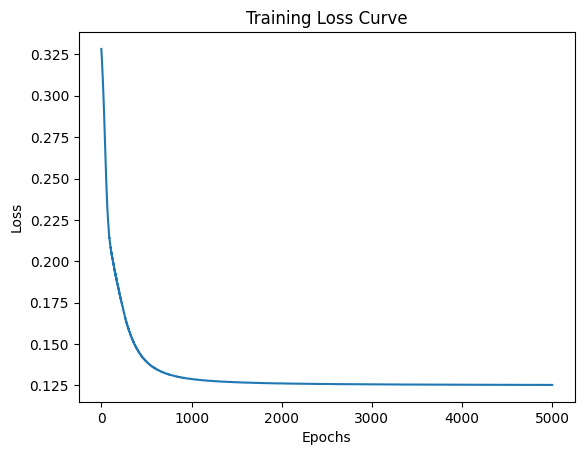

In [ ]:
import matplotlib.pyplot as plt

plt.plot(loss_values)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

## **2.Neural Network using Basic Python (From Scratch)**

In [ ]:
import numpy as np

# XOR dataset
X = np.array([[0,0], [0,1], [1,0], [1,1]])
Y = np.array([[0], [1], [1], [0]])

np.random.seed(42)

W1 = np.random.randn(2, 4)
b1 = np.zeros((1, 4))

W2 = np.random.randn(4, 1)
b2 = np.zeros((1, 1))

In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

In [ ]:
learning_rate = 0.1
epochs = 5000

losses = []

for epoch in range(epochs):

    # ---- Forward Propagation ----
    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)

    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)

    # ---- Loss (MSE) ----
    loss = np.mean((Y - A2) ** 2)
    losses.append(loss)

    # ---- Backpropagation ----
    dA2 = (A2 - Y)
    dZ2 = dA2 * sigmoid_derivative(A2)

    dW2 = np.dot(A1.T, dZ2)
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * relu_derivative(A1)

    dW1 = np.dot(X.T, dZ1)
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    # ---- Gradient Descent ----
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss}")

Epoch 0, Loss: 0.3554116985980176
Epoch 500, Loss: 0.1035491724896654
Epoch 1000, Loss: 0.014377146858852899
Epoch 1500, Loss: 0.005799052021212319
Epoch 2000, Loss: 0.0033991623784586002
Epoch 2500, Loss: 0.0023422213205867137
Epoch 3000, Loss: 0.0017645667013828526
Epoch 3500, Loss: 0.001403589787966631
Epoch 4000, Loss: 0.0011599540581900048
Epoch 4500, Loss: 0.0009843103544123547



Final Predictions:
[[0.04566402]
 [0.97781942]
 [0.97782072]
 [0.01855475]]


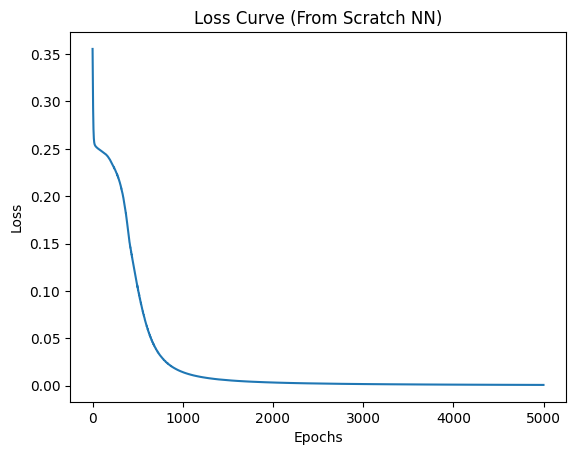

In [ ]:
print("\nFinal Predictions:")
print(A2)

import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve (From Scratch NN)")
plt.show()

## **3. Neural Network using Keras**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
data = load_iris()
X = data.data
y = data.target.reshape(-1, 1)

encoder = OneHotEncoder(sparse_output=False)
y = encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = Sequential()

model.add(Dense(10, activation='relu', input_shape=(4,)))
model.add(Dense(8, activation='relu'))
model.add(Dense(3, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    validation_data=(X_test, y_test),
    verbose=1
)
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 261ms/step - accuracy: 0.4583 - loss: 0.8760 - val_accuracy: 0.6000 - val_loss: 0.8626
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.4917 - loss: 0.8627 - val_accuracy: 0.6000 - val_loss: 0.8496
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5500 - loss: 0.8492 - val_accuracy: 0.7000 - val_loss: 0.8368
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.6000 - loss: 0.8360 - val_accuracy: 0.8333 - val_loss: 0.8244
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.6750 - loss: 0.8239 - val_accuracy: 0.8333 - val_loss: 0.8121
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.7000 - loss: 0.8114 - val_accuracy: 0.8667 - val_loss: 0.8005
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.7333 - loss: 0.8004 - val_accuracy: 0.8667 - val_loss: 0.7894
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.7583 - loss: 0.7892 - val_accuracy: 0.9000 - val_loss

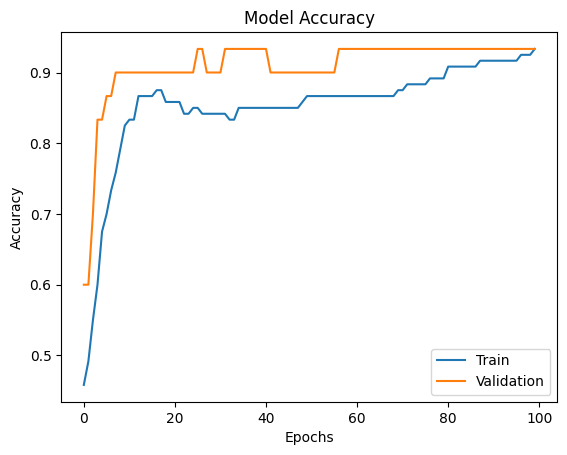

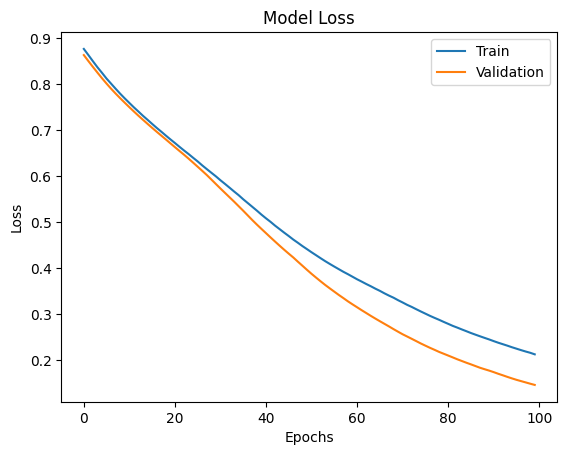

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

## **4. Agriculture Price Prediction (Regression Problem)**

In [ ]:
import numpy as np
import pandas as pd

# Create synthetic agriculture dataset
# Features: rainfall, temperature, fertilizer, area
np.random.seed(42)

data_size = 200

rainfall = np.random.uniform(50, 300, data_size)
temperature = np.random.uniform(15, 40, data_size)
fertilizer = np.random.uniform(10, 100, data_size)
area = np.random.uniform(1, 10, data_size)

# Target: crop price (some relation)
price = (0.5 * rainfall) + (2 * temperature) + (1.5 * fertilizer) + (10 * area) + np.random.randn(data_size)*20

df = pd.DataFrame({
    "rainfall": rainfall,
    "temperature": temperature,
    "fertilizer": fertilizer,
    "area": area,
    "price": price
})

df.head()

,rainfall,temperature,fertilizer,area,price
0,143.635030,31.050791,19.281148,2.520416,172.235486
1,287.678577,17.103499,91.229762,3.507313,359.393427
2,232.998485,19.040718,55.472714,2.593094,301.361182
3,199.664621,37.463855,84.381172,1.798323,346.223407
4,89.004660,30.160726,38.804464,2.085723,215.751440


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop("price", axis=1)
y = df["price"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(16, activation='relu', input_shape=(4,)),
    Dense(8, activation='relu'),
    Dense(1)  # No activation → regression
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)
history = model.fit(
    X_train, y_train,
    epochs=100,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 121ms/step - loss: 79091.4062 - mae: 273.8857 - val_loss: 88072.5938 - val_mae: 292.6091
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 79071.1406 - mae: 273.8475 - val_loss: 88050.5547 - val_mae: 292.5709
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 79050.9531 - mae: 273.8091 - val_loss: 88027.2969 - val_mae: 292.5305
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 79029.1172 - mae: 273.7686 - val_loss: 88002.5312 - val_mae: 292.4877
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 79006.2656 - mae: 273.7253 - val_loss: 87976.2266 - val_mae: 292.4427
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 150ms/step - loss: 78982.8281 - mae: 273.6815 - val_loss: 87948.3594 - val_mae: 292.3951
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 78956.6953 - mae: 273.6332 - val_loss: 87919.5391 - val_mae: 292.3460
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 78931.2109 - mae: 273.5853 - val_loss: 8788

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
MSE: 53943.57677457829
R2 Score: -9.71113370379998


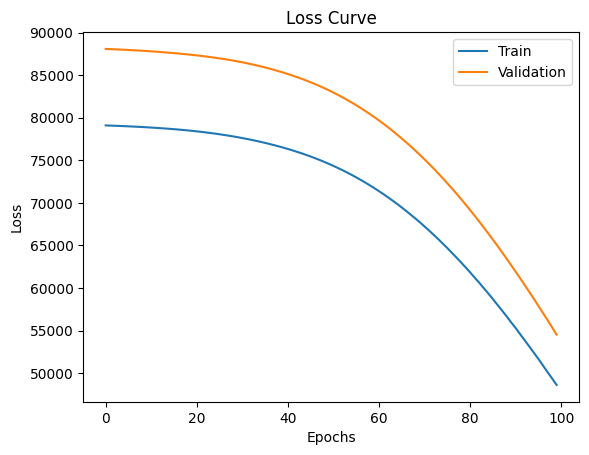

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# Predictions
y_pred = model.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 Score:", r2)

import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

## **5. MNIST Digit Classification using ANN**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


In [ ]:
# Normalize (0–255 → 0–1)
X_train = X_train / 255.0
X_test = X_test / 255.0

# Flatten (28x28 → 784)
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

# One-hot encoding
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    X_train, y_train_cat,
    epochs=10,
    validation_split=0.1,
    batch_size=32,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9254 - loss: 0.2568 - val_accuracy: 0.9687 - val_loss: 0.1144
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.9658 - loss: 0.1103 - val_accuracy: 0.9717 - val_loss: 0.0903
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9769 - loss: 0.0754 - val_accuracy: 0.9770 - val_loss: 0.0814
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9811 - loss: 0.0580 - val_accuracy: 0.9772 - val_loss: 0.0878
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9860 - loss: 0.0436 - val_accuracy: 0.9792 - val_loss: 0.0740
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9888 - loss: 0.0358 - val_accuracy: 0.9792 - val_loss: 0.0774
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9899 - loss: 0.0293 - val_accuracy: 0.9808 - val_loss: 0.0773
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9913 - loss: 0.0255 

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9740 - loss: 0.1167
Test Accuracy: 0.9739999771118164
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


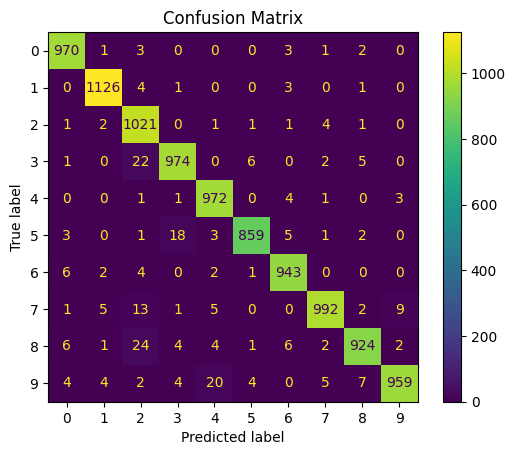

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Evaluate
loss, accuracy = model.evaluate(X_test, y_test_cat)
print("Test Accuracy:", accuracy)

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

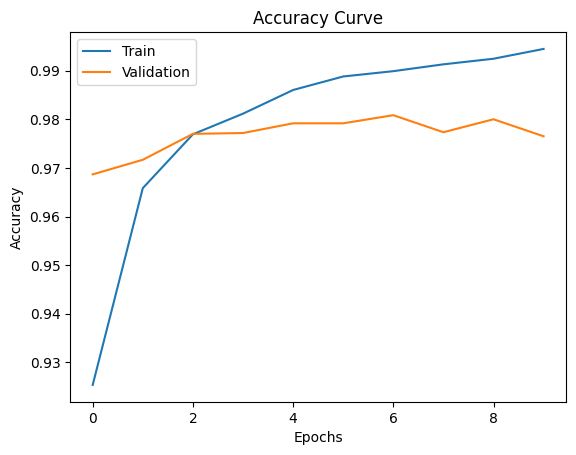

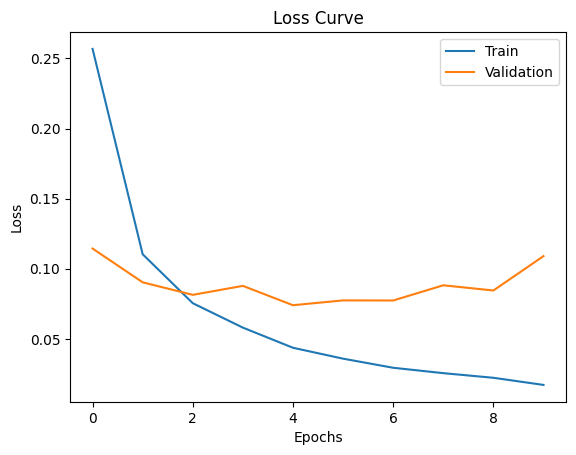

In [ ]:
# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

## **6. Plant Disease Detection using CNN**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [ ]:
train_dir = "/content/archive/train"
val_dir = "/content/archive/valid"
test_dir = "/content/archive/test"

In [ ]:
import os

# List the contents of the extracted 'archive' directory
archive_path = '/content/archive'
if os.path.exists(archive_path):
    print(f"Contents of {archive_path}: {os.listdir(archive_path)}")
else:
    print(f"Directory {archive_path} not found.")

Contents of /content/archive: ['train']


In [ ]:
import os

print(os.listdir('/content'))

['.config', 'sample_data']


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import zipfile
import os

# Unzip the uploaded dataset if it exists
zip_file_path = 'archive.zip'
if os.path.exists(zip_file_path):
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall('/content') # Changed extraction path to '/content'
    print(f"'{zip_file_path}' extracted to '/content'")
else:
    print(f"'{zip_file_path}' not found. Please ensure the dataset is uploaded.")

img_size = (128, 128)
batch_size = 32

train_datagen = ImageDataGenerator(rescale=1./255)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

val_data = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_data = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)